In [194]:
'''
Author: zhangshd
Date: 2025-05-16
Description: Example Jupyter notebook demonstrating interactive visualization of atom importance
'''
%load_ext autoreload
%autoreload 2
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add src directory to path
ROOT_DIR = Path(".").resolve().parent
sys.path.append(str(ROOT_DIR))

# Import necessary modules
from src.cgcnn.visualization.atom_visualizer import AtomImportanceVisualizer
from src.cgcnn.visualization.feature_visualizer import FeatureImportanceVisualizer
from src.cgcnn.module.att_cgcnn import CrystalGraphConvNet
from src.cgcnn.inference import InferenceDataset
from src.cgcnn.utils import load_model_from_dir
from src.cgcnn.datamodule.prepare_data import _make_supercell
import traceback
import ipywidgets as widgets
from IPython.display import display

# Set matplotlib to show plots inline
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
# Introduction
print("# Interactive Atom Importance Visualization Demo")
print("This notebook demonstrates how to use NGLView for interactive visualization of atom importance in MOF structures.")
print("\n## 1. Load Model and Dataset")

# Load model
model_path = ROOT_DIR/'results/cgcnn_models/TSD_SSD_WS24_water_WS24_water4_WS24_acid_WS24_base_WS24_boiling_seed42_att_cgcnn/version_43'
model_checkpoint = list(model_path.glob('*/best*.ckpt'))[0]
print(f"Loading model from: {model_checkpoint}")

def load_model(checkpoint_path):
    """Load a trained CrystalGraphConvNet model from checkpoint"""
    checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))
    
    # Initialize model
    model = CrystalGraphConvNet(**checkpoint["hyper_parameters"])
    
    # Load state dict
    model.load_state_dict({k.replace("model.", ""):v for k,v in checkpoint['state_dict'].items()})
    model.eval()
    
    return model

try:
    # model = load_model(model_checkpoint)
    model, trainer = load_model_from_dir(model_path, accelerator="cpu")
    model = model.model
    print(f"Model loaded successfully")
    print(f"Task types: {model.kwargs['task_types']}")
    print(f"Using attention pooling: {model.kwargs['att_pooling']}")
except Exception as e:
    print(f"Error loading model: {e}")
    print("Please update the path to your trained model and try again")

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


# Interactive Atom Importance Visualization Demo
This notebook demonstrates how to use NGLView for interactive visualization of atom importance in MOF structures.

## 1. Load Model and Dataset
Loading model from: /home/zhangsd/repos/MOFSNN/results/cgcnn_models/TSD_SSD_WS24_water_WS24_water4_WS24_acid_WS24_base_WS24_boiling_seed42_att_cgcnn/version_43/checkpoints/best-epoch=108-val_Metric=0.608.ckpt
task_types:  ['regression', 'classification', 'classification', 'classification_4', 'classification', 'classification', 'classification']
Loading the best model checkpoint: /home/zhangsd/repos/MOFSNN/results/cgcnn_models/TSD_SSD_WS24_water_WS24_water4_WS24_acid_WS24_base_WS24_boiling_seed42_att_cgcnn/version_43/checkpoints/best-epoch=108-val_Metric=0.608.ckpt
Model loaded successfully
Task types: ['regression', 'classification', 'classification', 'classification_4', 'classification', 'classification', 'classification']
Using attention pooling: False


In [189]:
# Load example CIF file
print("\n## 2. Load MOF Structure")
cif_dir = ROOT_DIR/'data/example_cifs'
# cif_dir = ROOT_DIR/'data/cgcnn_data/SSD/cifs'
print(f"Looking for CIF files in: {cif_dir}")
cif_files = list(cif_dir.glob('*.cif'))

# Select a CIF file
cif_path = str(cif_files[0])
cif_path = ROOT_DIR/'data/example_cifs/CALF20.cif'
# cif_path = ROOT_DIR/'data/example_cifs/Cu-BTC.cif'

## 2 samples in SSD task with similar structure but different predicted values
# cif_path = ROOT_DIR/'data/cgcnn_data/SSD/cifs/AZAWAB_clean.cif'
# cif_path = ROOT_DIR/'data/cgcnn_data/SSD/cifs/AZAVUU_clean.cif'

# cif_path = ROOT_DIR/'data/cgcnn_data/SSD/cifs/NEXVET_clean.cif'
cif_path = ROOT_DIR/'data/cgcnn_data/SSD/cifs/ECEZAO01_clean.cif'
# cif_path = ROOT_DIR/'data/cgcnn_data/SSD/cifs/NUNNUH_clean.cif'

print(f"Using CIF file: {cif_path}")

# Create inference dataset
def load_dataset(cif_path):
    """Load data from a CIF file"""
    temp_dir = Path('./temp_inference')
    temp_dir.mkdir(exist_ok=True)
    
    dataset = InferenceDataset(
        [cif_path], 
        saved_dir=temp_dir,
        **{k:v for k,v in model.kwargs.items() if k not in ["saved_dir"]},
    )
    
    dataset.setup()
    return dataset

dataset = load_dataset(cif_path)
print(f"CIF data loaded successfully")


## 2. Load MOF Structure
Looking for CIF files in: /home/zhangsd/repos/MOFSNN/data/example_cifs
Using CIF file: /home/zhangsd/repos/MOFSNN/data/cgcnn_data/SSD/cifs/ECEZAO01_clean.cif
('cell vectors: ', 'alpha, beta, gamma = 116.453, 96.3409, 90.0')
n_components: 1
labels_components: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0]
len is 49
CIF data loaded successfully


In [195]:
# Process data
print("\n## 3. Prepare Data for Visualization")

# Get data for the structure
data_dict = dataset[0]
atom_fea = data_dict["atom_fea"] 
nbr_fea = data_dict["nbr_fea"]
nbr_fea_idx = data_dict["nbr_fea_idx"]
extra_fea = data_dict["extra_fea"]
cif_id = data_dict["cif_id"]

# Get atom coordinates and elements
from ase.io import read
structure = read(cif_path)
structure = _make_supercell(structure, model.kwargs["radius"])
atom_coords = structure.get_positions()
atom_elements = structure.get_chemical_symbols()
print(f"Number of atoms: {len(atom_elements)}")

# Process into a batch
data_batch = dataset.collate([data_dict])
atom_fea_batch = data_batch["atom_fea"]
nbr_fea_batch = data_batch["nbr_fea"]
nbr_fea_idx_batch = data_batch["nbr_fea_idx"]
crystal_atom_idx_batch = data_batch["crystal_atom_idx"]



## 3. Prepare Data for Visualization
Number of atoms: 98



## 4. Calculate Atom Importance
TSD (regression):


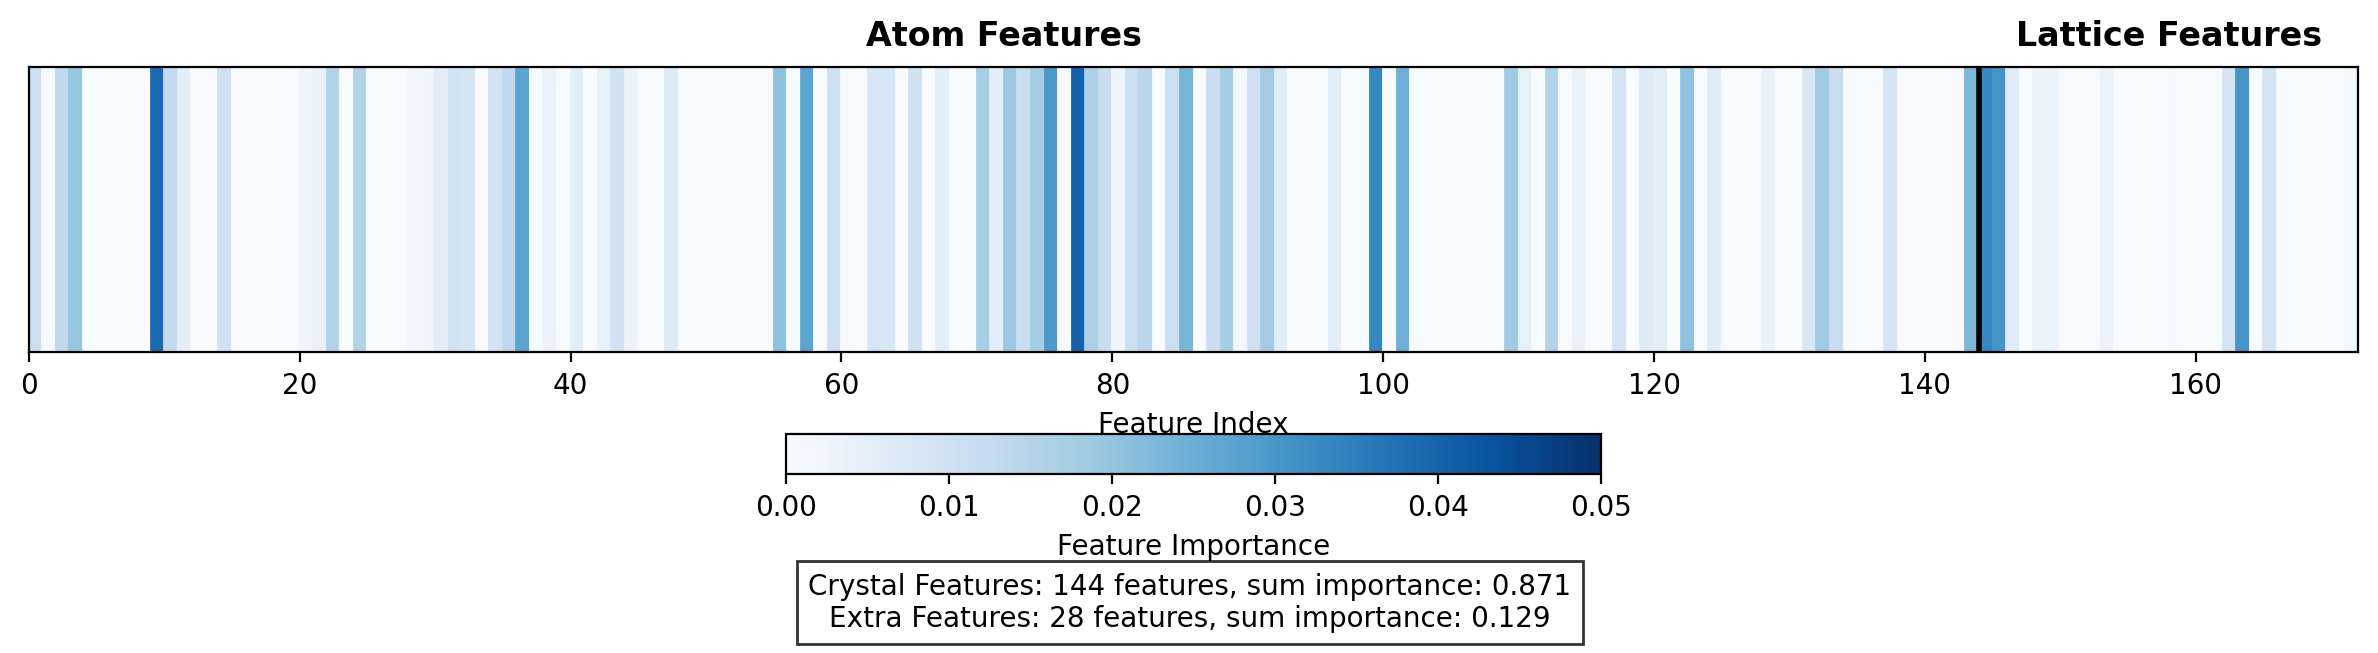

SSD (classification):


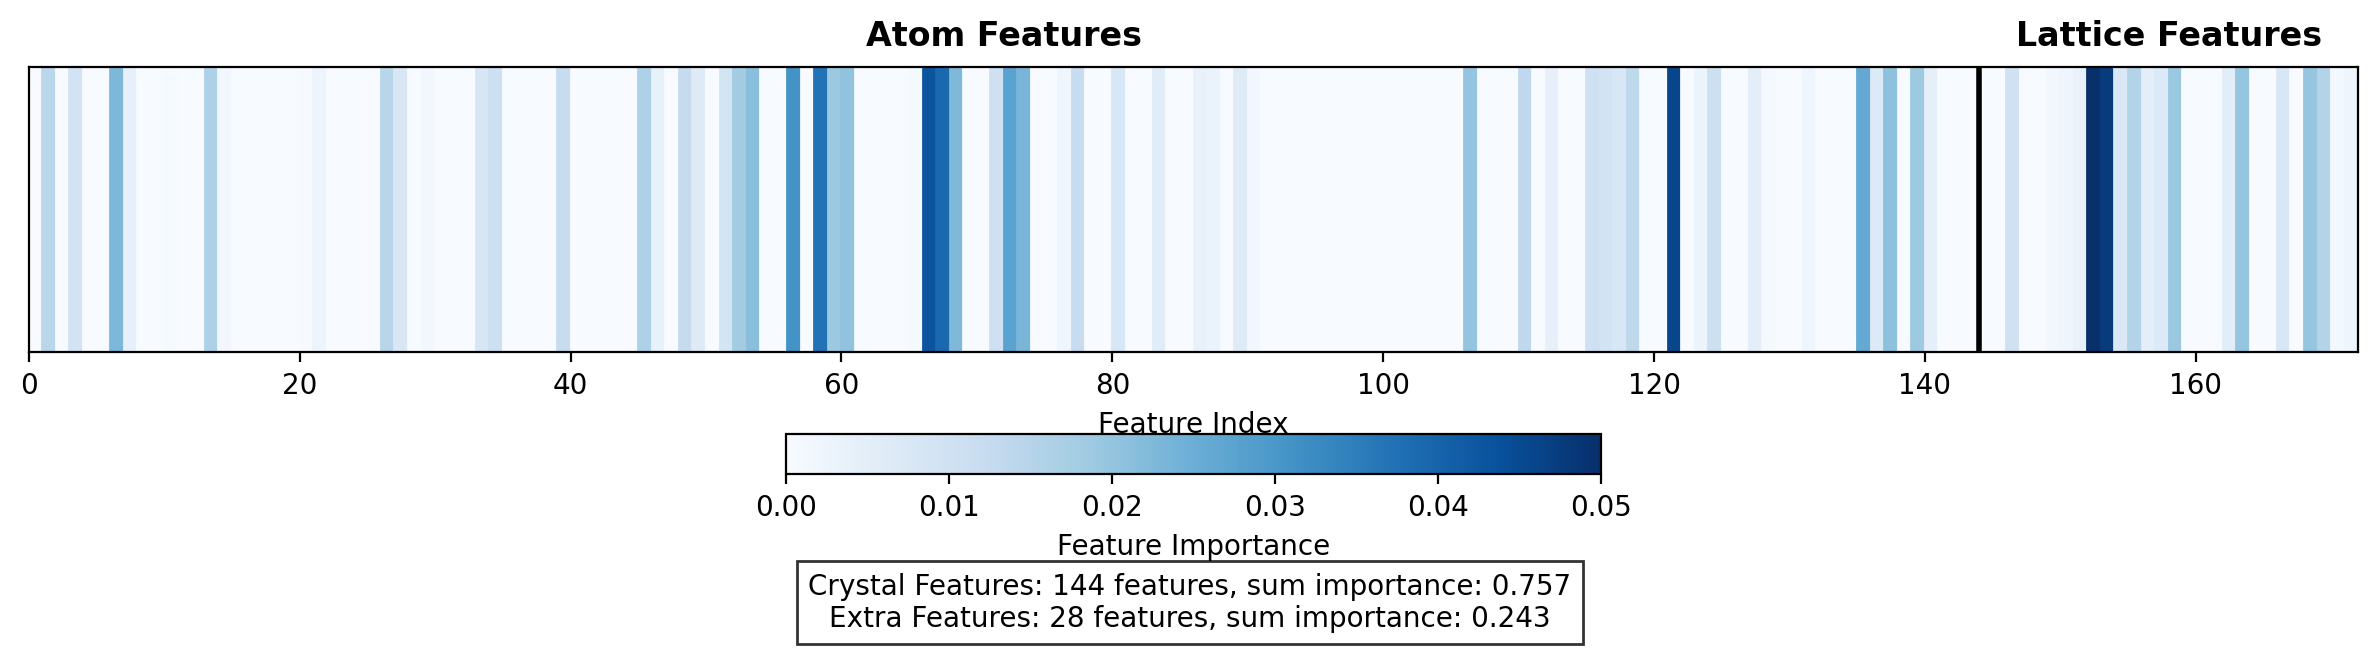

WS24_water (classification):


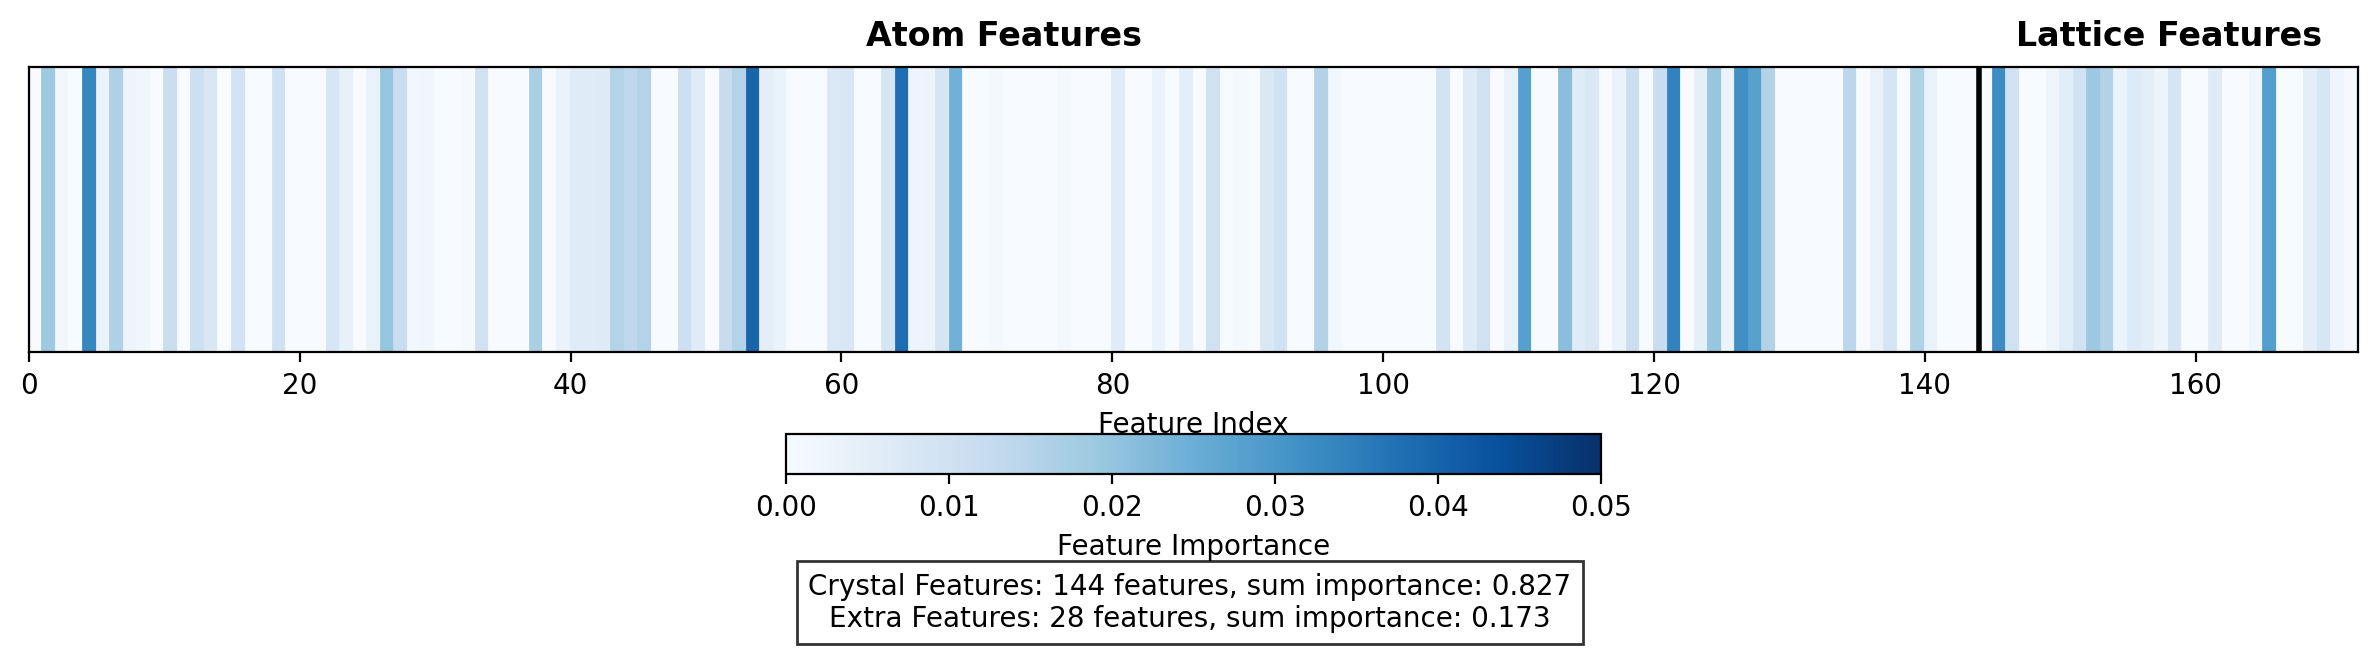

WS24_water4 (classification_4):


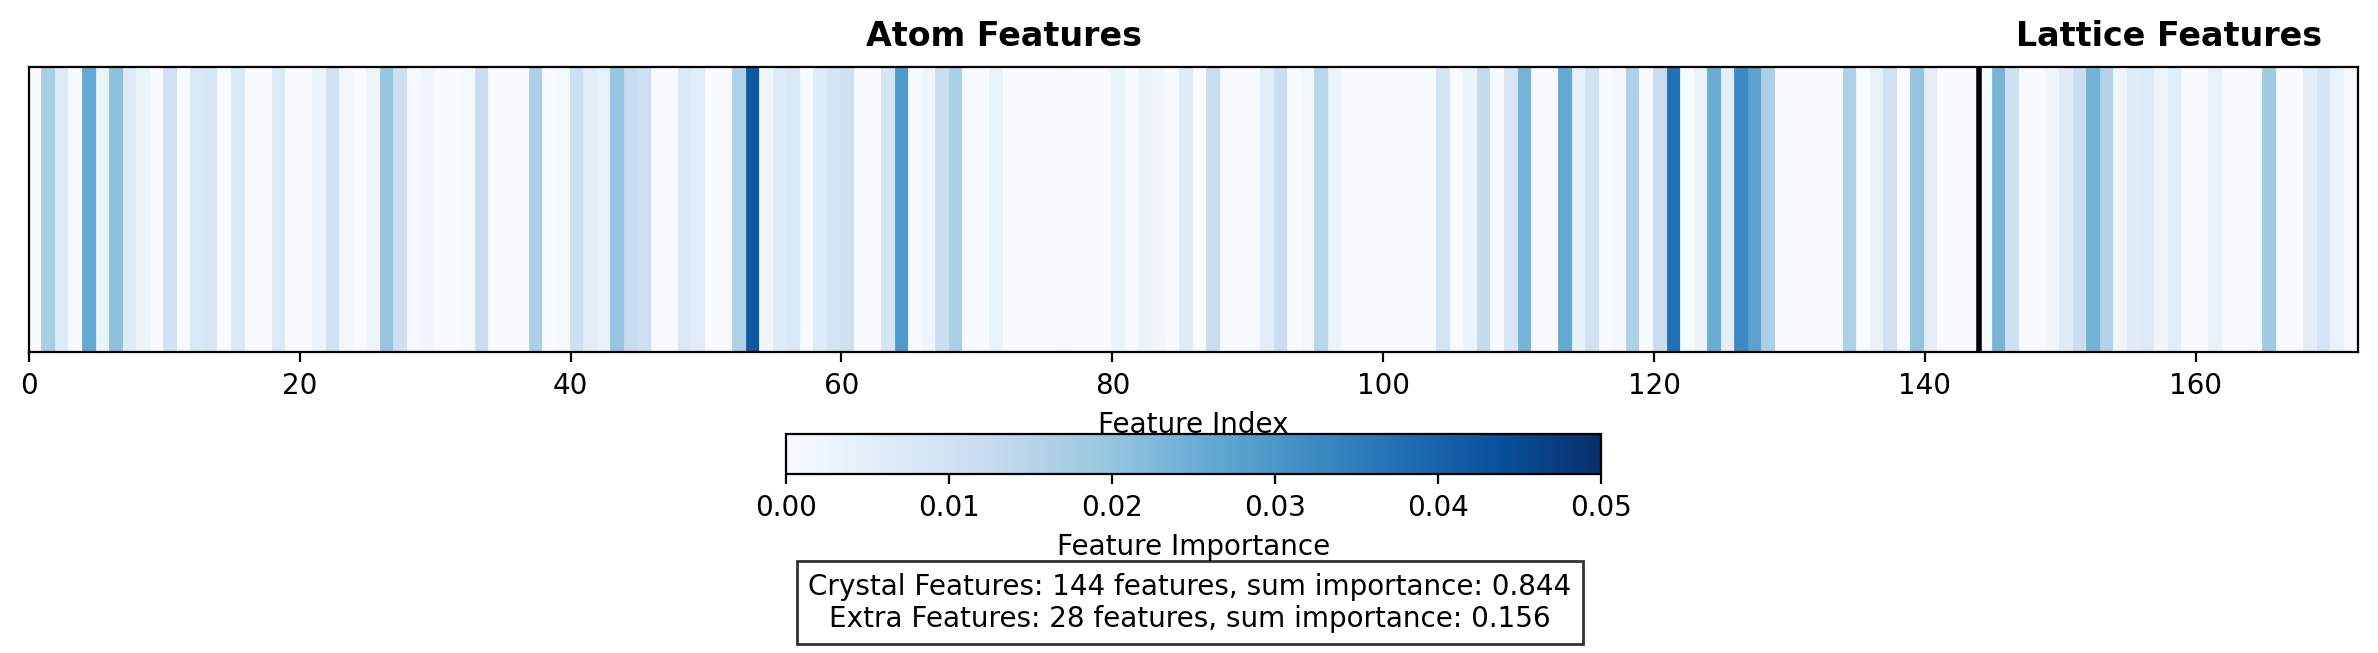

WS24_acid (classification):


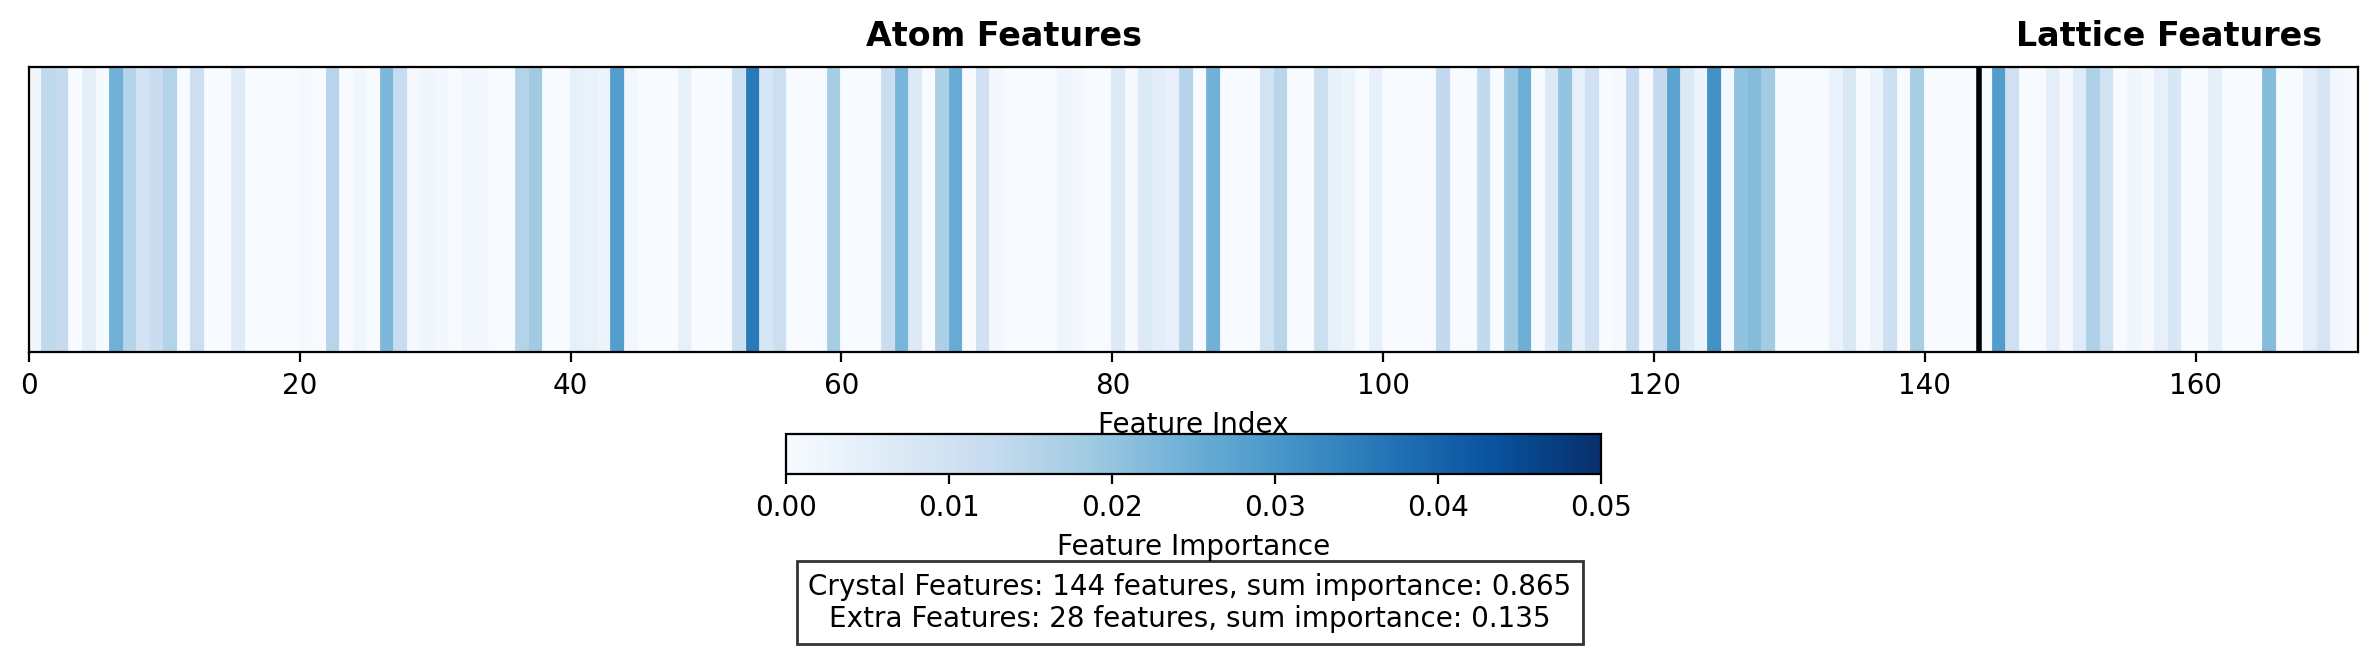

WS24_base (classification):


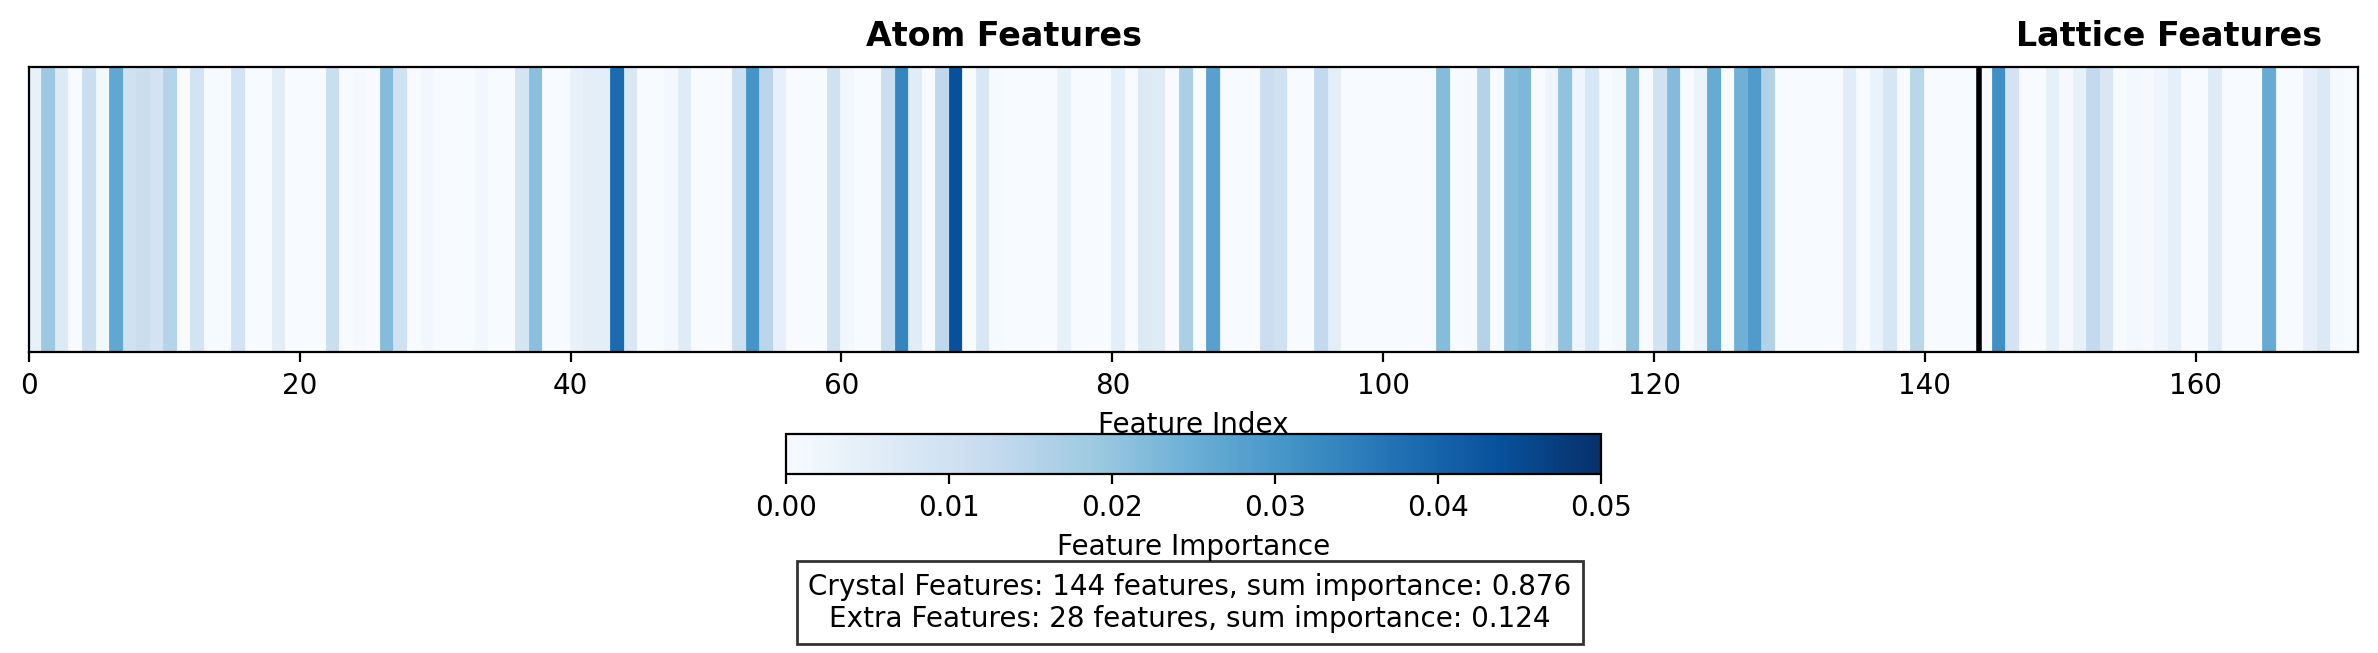

WS24_boiling (classification):


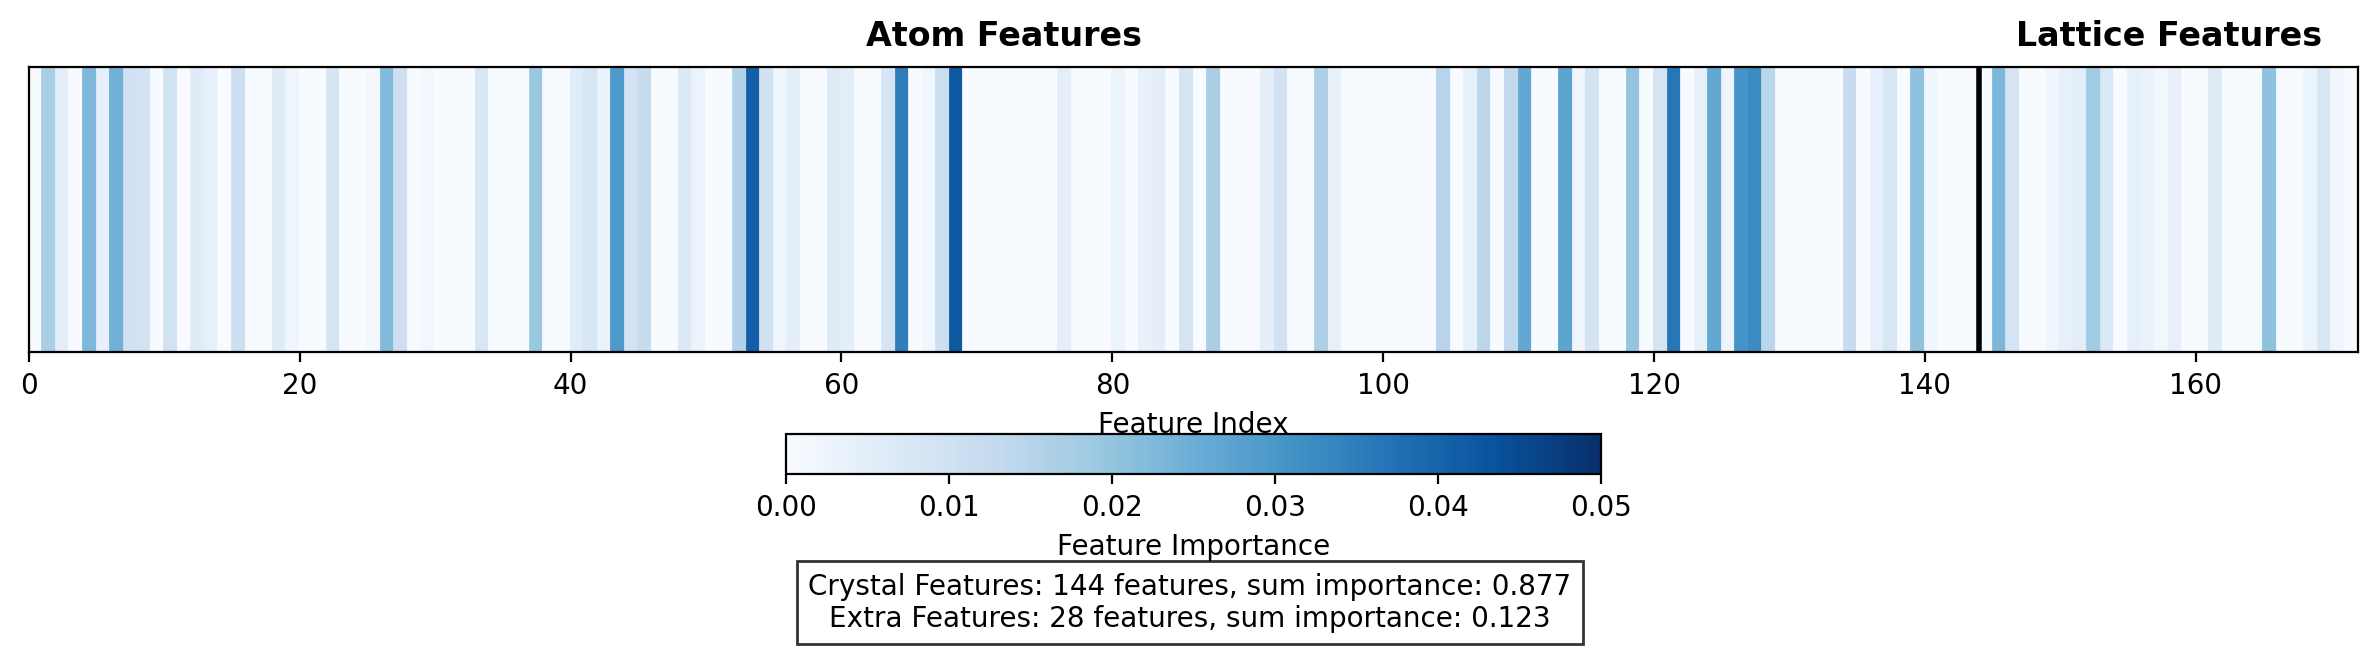


Atom Importance Summary:
TSD (regression): mean=0.0058, max=0.0406
SSD (classification): mean=0.0058, max=0.0515
WS24_water (classification): mean=0.0058, max=0.0397
WS24_water4 (classification_4): mean=0.0058, max=0.0420
WS24_acid (classification): mean=0.0058, max=0.0360
WS24_base (classification): mean=0.0058, max=0.0439
WS24_boiling (classification): mean=0.0058, max=0.0421


In [196]:
# Create visualizer

visualizer = FeatureImportanceVisualizer(model)

print("\n## 4. Calculate Atom Importance")
# Calculate atom importance for all tasks
task_results = {}
figs = []
for task_idx in range(len(model.task_types)):
    print("="*50)
    print(f"{model.kwargs['tasks'][task_idx]} ({model.task_types[task_idx]}):")
    result = visualizer.calculate_feature_importance(
        atom_fea_batch, nbr_fea_batch, nbr_fea_idx_batch, crystal_atom_idx_batch,
        extra_fea=data_batch["extra_fea"], task_idx=task_idx,
    )
    # print(f"  Atom importance shape: {result['atom_importance'][0].shape}")
    task_results[task_idx] = result
    fig = visualizer.visualize_feature_importance(result, colormap="Blues")
    figs.append(fig)
    plt.show()
    
# Print summary of atom importance scores for each task
print("\nAtom Importance Summary:")
for task_idx, importance in task_results.items():
    print(f"{model.kwargs['tasks'][task_idx]} ({model.task_types[task_idx]}): mean={np.mean(importance['per_sample_importance'][0]):.4f}, max={np.max(importance['per_sample_importance'][0]):.4f}")

In [197]:
# Create visualizer

visualizer = AtomImportanceVisualizer(model)

print("\n## 4. Calculate Atom Importance")
# Calculate atom importance for all tasks
task_results = {}
method='grad_cam'
for task_idx in range(len(model.task_types)):
    print("="*50)
    print(f"{model.kwargs['tasks'][task_idx]} ({model.task_types[task_idx]}):")
    result = visualizer.calculate_atom_importance(
        atom_fea_batch, nbr_fea_batch, nbr_fea_idx_batch, crystal_atom_idx_batch,
        extra_fea=data_batch["extra_fea"], task_idx=task_idx, return_gradients=False,
        method=method,
    )
    
    print(f"  Atom importance shape: {result['atom_importance'][0].shape}")
    task_results[task_idx] = result['atom_importance'][0]
    
# Print summary of atom importance scores for each task
print("\nAtom Importance Summary:")
for task_idx, importance in task_results.items():
    print(f"Task {task_idx} ({model.task_types[task_idx]}): mean={np.mean(importance):.4f}, max={np.max(importance):.4f}")



## 4. Calculate Atom Importance
TSD (regression):
Predicted output [grad_cam]: tensor([[0.1881]], grad_fn=<AddmmBackward0>)
Atom importance scores (ReLU applied): 0.0, 0.02009783312678337
  Atom importance shape: (98,)
SSD (classification):
Predicted output [grad_cam]: tensor([[-0.4589, -0.9997]], grad_fn=<LogSoftmaxBackward0>)
Atom importance scores (ReLU applied): 0.0, 0.0167294442653656
  Atom importance shape: (98,)
WS24_water (classification):
Predicted output [grad_cam]: tensor([[-1.9910e-03, -6.2202e+00]], grad_fn=<LogSoftmaxBackward0>)
Atom importance scores (ReLU applied): 0.0, 0.22584697604179382
  Atom importance shape: (98,)
WS24_water4 (classification_4):
Predicted output [grad_cam]: tensor([[-5.1070e+00, -7.4770e-03, -7.4860e+00, -7.0890e+00]],
       grad_fn=<LogSoftmaxBackward0>)
Atom importance scores (ReLU applied): 0.0, 0.0003741839900612831
  Atom importance shape: (98,)
WS24_acid (classification):
Predicted output [grad_cam]: tensor([[-1.4226e-03, -6.5560e+00]], g

In [198]:
# Analysis of top important atoms
print("\n## 8. Identify and Analyze Top Important Atoms")
# Number of top atoms to analyze
top_n = 5

for task_idx in range(len(model.task_types)):
    importance = task_results[task_idx]
    top_indices = np.argsort(-np.abs(importance))[:top_n]  # Sort by descending importance
    
    print(f"\n{model.kwargs['tasks'][task_idx]} ({model.task_types[task_idx]})")
    print(f"Top {top_n} most important atoms:")
    for i, idx in enumerate(top_indices):
        element = atom_elements[idx]
        score = importance[idx]
        coords = atom_coords[idx]
        print(f"  {i+1}. {element} (atom {idx}): score = {score:.4f}, coordinates = [{coords[0]:.2f}, {coords[1]:.2f}, {coords[2]:.2f}]")
        
    # Analyze element types in top atoms
    top_elements = [atom_elements[idx] for idx in top_indices]
    element_counts = {}
    for elem in top_elements:
        element_counts[elem] = element_counts.get(elem, 0) + 1
    
    print(f"  Element distribution in top {top_n} atoms:")
    for elem, count in element_counts.items():
        print(f"    {elem}: {count} atoms ({count/top_n*100:.1f}%)")


## 8. Identify and Analyze Top Important Atoms

TSD (regression)
Top 5 most important atoms:
  1. C (atom 79): score = 1.0000, coordinates = [11.51, 8.28, 2.22]
  2. H (atom 68): score = 1.0000, coordinates = [10.58, -2.27, 6.56]
  3. C (atom 30): score = 1.0000, coordinates = [5.14, 8.28, 2.22]
  4. H (atom 19): score = 1.0000, coordinates = [4.20, -2.27, 6.56]
  5. Ni (atom 0): score = 0.3595, coordinates = [3.19, 8.49, 0.00]
  Element distribution in top 5 atoms:
    C: 2 atoms (40.0%)
    H: 2 atoms (40.0%)
    Ni: 1 atoms (20.0%)

SSD (classification)
Top 5 most important atoms:
  1. O (atom 95): score = 1.0000, coordinates = [5.38, -3.52, 8.52]
  2. O (atom 46): score = 1.0000, coordinates = [-0.99, -3.52, 8.52]
  3. H (atom 52): score = 1.0000, coordinates = [6.04, 1.91, 6.57]
  4. H (atom 3): score = 1.0000, coordinates = [-0.33, 1.91, 6.57]
  5. O (atom 45): score = 1.0000, coordinates = [1.20, -3.35, 8.07]
  Element distribution in top 5 atoms:
    O: 3 atoms (60.0%)
    H: 


## 6. Interactive NGLView Visualization
NGLView is available. Creating interactive visualization...


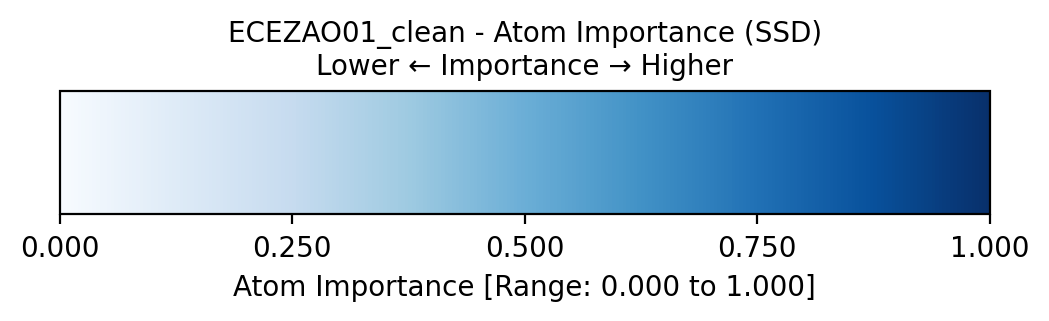

Visualization: ECEZAO01_clean - Atom Importance (SSD)
Total atoms: 98
Importance range: [0.000, 1.000]
Color mapping range: [0.000, 1.000]
Atoms above importance threshold (0.70): 8

Interactive visualization controls:
- Left mouse: Rotate
- Right mouse: Zoom
- Middle mouse: Pan
- Double-click: Center on atom


In [199]:

# Choose a task to visualize
task_idx = 1  # Change this to visualize different tasks

# Visualization parameters
figsize = (12, 10)
colormap = 'bwr' if "no_relu" in method else 'Blues'
highlight_threshold = 0.7

# Interactive Visualization
print("\n## 6. Interactive NGLView Visualization")
try:
    # Check if NGLView is available
    import nglview
    print("NGLView is available. Creating interactive visualization...")
    
    # Create an interactive visualization using NGLView
    ngl_view = visualizer.visualize_atom_importance(
        atoms=structure,
        atom_importance=task_results[task_idx],
        atom_elements=atom_elements,
        title=f"{cif_id} - Atom Importance ({model.kwargs['tasks'][task_idx]})",
        colormap=colormap,
        highlight_threshold=highlight_threshold
    )
    
    if ngl_view is not None:
        print("\nInteractive visualization controls:")
        print("- Left mouse: Rotate")
        print("- Right mouse: Zoom")
        print("- Middle mouse: Pan")
        print("- Double-click: Center on atom")
    else:
        print("Failed to create NGLView visualization.")
except ImportError:
    print("NGLView is not installed. To enable interactive visualization, install it with:")
    print("pip install nglview")
except Exception as e:
    traceback.print_exc()

In [202]:
ngl_view

NGLWidget(n_components=1, picked={'atom1': {'index': 4, 'residueIndex': 0, 'resname': 'MOL', 'x': 4.2039999961…